In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [6]:
df = pd.read_csv("../Data/raw/synthetic_it_support_tickets.csv")

In [ ]:
df["priority"].unique()

array(['low', 'medium', 'urgent', 'high'], dtype=object)

<Axes: xlabel='priority'>

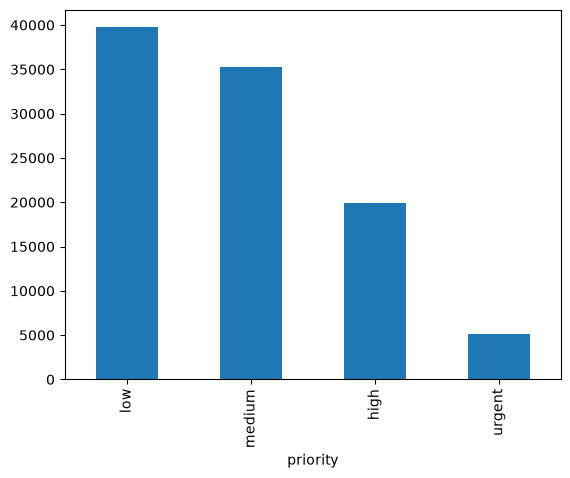

In [ ]:
df["priority"].value_counts().plot(kind="bar")

In [ ]:
categorical_columns = [
    "customer_segment",
    "channel",
    "product_area",
    "issue_type",
    "priority",
    "status",
    "sla_plan",
    "customer_sentiment",
    "platform",
    "region"
]

for col in categorical_columns:
    print("=" * 50)
    print(f"Column: {col}")
    print(df[col].unique())
    print("\n")

Column: customer_segment
['individual' 'small_business' 'education' 'enterprise' 'non_profit']


Column: channel
['email' 'in_app' 'chat' 'phone_transcript' 'web_form']


Column: product_area
['data_export' 'billing' 'api_integration' 'analytics_dashboard'
 'login_auth' 'mobile_app' 'notifications']


Column: issue_type
['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']


Column: priority
['low' 'medium' 'urgent' 'high']


Column: status
['resolved' 'closed_no_action' 'in_progress' 'on_hold' 'open']


Column: sla_plan
['standard' 'gold' 'platinum']


Column: customer_sentiment
['very_negative' 'neutral' 'positive' 'negative' 'very_positive']


Column: platform
['android' 'web' 'ios' 'api_client' 'desktop_app']


Column: region
['EU' nan 'MEA' 'LATAM' 'APAC']




In [ ]:
df["region"]=df["region"].fillna("Unknown") 

 

In [ ]:
df["region"].value_counts()

region
MEA        20151
Unknown    19997
EU         19960
LATAM      19959
APAC       19933
Name: count, dtype: int64

In [ ]:
expected_values = {
    "customer_segment": [
        "individual", "small_business", "education",
        "enterprise", "non_profit"
    ],
    
    "channel": [
        "email", "in_app", "chat",
        "phone_transcript", "web_form"
    ],
    
    "priority": [
        "low", "medium", "high", "urgent"
    ],
    
    "status": [
        "resolved", "closed_no_action",
        "in_progress", "on_hold", "open"
    ],
    
    "sla_plan": [
        "standard", "gold", "platinum"
    ],
    
    "customer_sentiment": [
        "very_negative", "negative", "neutral",
        "positive", "very_positive"
    ],
    
    "platform": [
        "android", "web", "ios",
        "api_client", "desktop_app"
    ],
    
    "region": [
        "EU", "MEA", "LATAM", "APAC"
    ]
}

In [ ]:
for col, expected in expected_values.items():
    actual = df[col].dropna().unique()
    invalid = [value for value in actual if value not in expected]
    
    print(f"{col}: {invalid}")

customer_segment: []
channel: []
priority: []
status: []
sla_plan: []
customer_sentiment: []
platform: []
region: ['Unknown']


In [ ]:
df["csat_score"].unique()

array([1, 3, 5, 2, 0, 4])

In [ ]:
df["reopened"].unique()

array([0, 1])

In [ ]:
df["has_attachment"].unique()

array([0, 1])

In [ ]:
df["resolution_time_hours"].describe()

count    60113.000000
mean        45.013123
std         49.202797
min          0.110000
25%         14.880000
50%         29.910000
75%         51.660000
max        239.960000
Name: resolution_time_hours, dtype: float64

In [ ]:
Q1 = df["resolution_time_hours"].quantile(0.25)
Q3 = df["resolution_time_hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 14.88
Q3: 51.66
IQR: 36.779999999999994
Lower Bound: -40.289999999999985
Upper Bound: 106.82999999999998


In [ ]:
outliers = df[(df["resolution_time_hours"] < lower_bound) | 
(df["resolution_time_hours"] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 6108


In [ ]:
df["resolution_time_hours"].describe()

count    60113.000000
mean        45.013123
std         49.202797
min          0.110000
25%         14.880000
50%         29.910000
75%         51.660000
max        239.960000
Name: resolution_time_hours, dtype: float64

In [ ]:
for col in ["issue_type", "priority", "status"]:
    print("\n" + "=" * 50)
    print(f"OUTLIERS BY {col.upper()}")
    print(outliers[col].value_counts())


OUTLIERS BY ISSUE_TYPE
issue_type
how_to              793
security_concern    779
feature_request     776
billing_problem     775
account_access      774
performance         748
bug                 736
other               727
Name: count, dtype: int64

OUTLIERS BY PRIORITY
priority
low       2462
medium    2134
high      1178
urgent     334
Name: count, dtype: int64

OUTLIERS BY STATUS
status
closed_no_action    6108
Name: count, dtype: int64


In [ ]:
outliers[ [
    "ticket_id" , "issue_type", "priority", "status", "resolution_time_hours"
] ]. head(20)

,ticket_id,issue_type,priority,status,resolution_time_hours
1,TCKT_000002,security_concern,medium,closed_no_action,238.32
5,TCKT_000006,performance,low,closed_no_action,226.93
20,TCKT_000021,feature_request,urgent,closed_no_action,214.65
24,TCKT_000025,how_to,low,closed_no_action,216.68
73,TCKT_000074,how_to,low,closed_no_action,180.15
84,TCKT_000085,performance,medium,closed_no_action,150.63
88,TCKT_000089,security_concern,high,closed_no_action,127.86
95,TCKT_000096,how_to,urgent,closed_no_action,111.78
124,TCKT_000125,billing_problem,low,closed_no_action,144.14
129,TCKT_000130,performance,medium,closed_no_action,208.51


In [ ]:
len(outliers)

6108

In [ ]:
len(outliers)/len(df)*100

6.1080000000000005

In [ ]:
print("Total rows:", len(df))
print("Potential outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / len(df) * 100)

Total rows: 100000
Potential outliers: 6108
Outlier percentage: 6.1080000000000005


In [ ]:
categorical_columns = [
    "customer_segment",
    "channel",
    "product_area",
    "issue_type",
    "priority",
    "status",
    "sla_plan",
    "customer_sentiment",
    "platform",
    "region"
]




In [ ]:
for col in categorical_columns:
    print("="*50)
    print(f"\n{col}")
    print("=" * 50)
    print(df[col].unique())


customer_segment
['individual' 'small_business' 'education' 'enterprise' 'non_profit']

channel
['email' 'in_app' 'chat' 'phone_transcript' 'web_form']

product_area
['data_export' 'billing' 'api_integration' 'analytics_dashboard'
 'login_auth' 'mobile_app' 'notifications']

issue_type
['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']

priority
['low' 'medium' 'urgent' 'high']

status
['resolved' 'closed_no_action' 'in_progress' 'on_hold' 'open']

sla_plan
['standard' 'gold' 'platinum']

customer_sentiment
['very_negative' 'neutral' 'positive' 'negative' 'very_positive']

platform
['android' 'web' 'ios' 'api_client' 'desktop_app']

region
['EU' 'Unknown' 'MEA' 'LATAM' 'APAC']


In [ ]:
for col in categorical_columns:
    print("=" * 50)
    print(f"Column: {col}")
    print(df[col].astype(str).str.strip().unique())

Column: customer_segment
['individual' 'small_business' 'education' 'enterprise' 'non_profit']
Column: channel
['email' 'in_app' 'chat' 'phone_transcript' 'web_form']
Column: product_area
['data_export' 'billing' 'api_integration' 'analytics_dashboard'
 'login_auth' 'mobile_app' 'notifications']
Column: issue_type
['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']
Column: priority
['low' 'medium' 'urgent' 'high']
Column: status
['resolved' 'closed_no_action' 'in_progress' 'on_hold' 'open']
Column: sla_plan
['standard' 'gold' 'platinum']
Column: customer_sentiment
['very_negative' 'neutral' 'positive' 'negative' 'very_positive']
Column: platform
['android' 'web' 'ios' 'api_client' 'desktop_app']
Column: region
['EU' 'Unknown' 'MEA' 'LATAM' 'APAC']


In [7]:
allowed_values = {
    "priority": ["low", "medium", "high", "urgent"],
    
    "status": [
        "resolved",
        "closed_no_action",
        "in_progress",
        "on_hold",
        "open"
    ],
    
    "sla_plan": [
        "standard",
        "gold",
        "platinum"
    ],
    
    "customer_sentiment": [
        "very_negative",
        "negative",
        "neutral",
        "positive",
        "very_positive"
    ],
    
    "region": [
        "EU",
        "MEA",
        "LATAM",
        "APAC"
    ]
}

In [13]:
for col, allowed in allowed_values.items():
    
    invalid = df[~df[col].isin(allowed)]
    
    print("=" * 50)
    print(f"Column: {col}")
    print("Invalid values:", len(invalid))

Column: priority
Invalid values: 0
Column: status
Invalid values: 0
Column: sla_plan
Invalid values: 0
Column: customer_sentiment
Invalid values: 0
Column: region
Invalid values: 0


In [12]:
df["region"].isnull().sum()

np.int64(0)

In [11]:
df["region"] = df["region"].fillna(df["region"].mode()[0])

In [19]:
df.to_csv("../Data/cleaned/it_support_cleaned.csv" , index= False)

In [20]:
import os

os.path.exists("../Data/cleaned/it_support_cleaned.csv ")

True